<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **DBSCAN**


Density-Based Spatial Clustering of Applications with Noise (DBSCAN) is a base algorithm for density-based clustering.
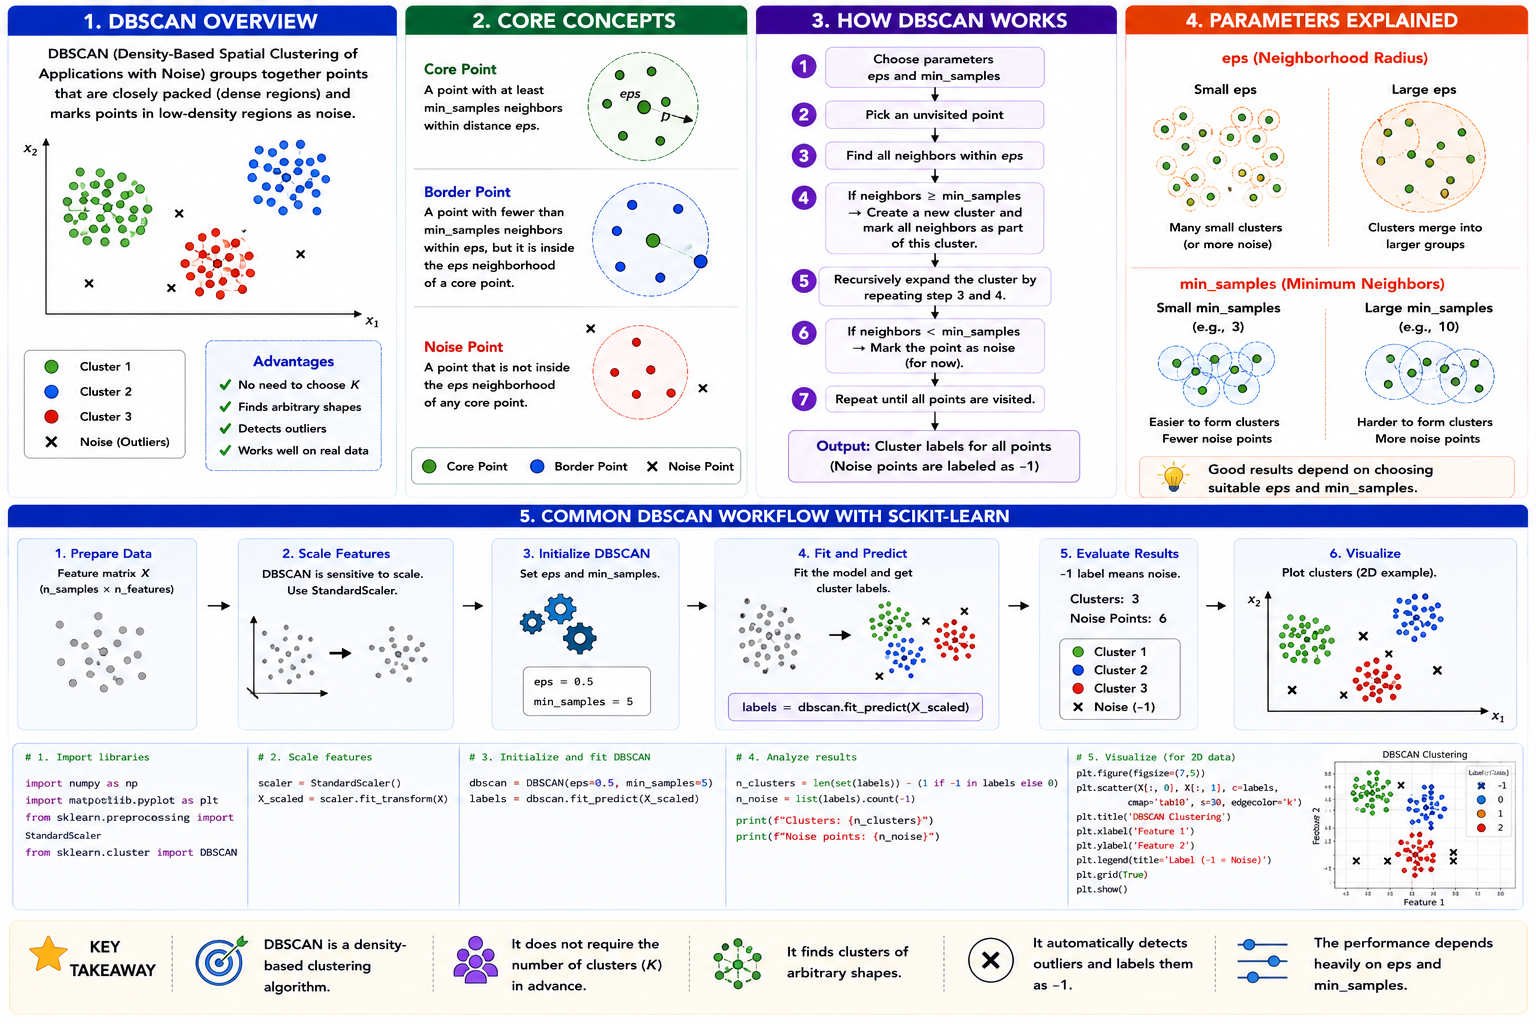
## **Use cases of DBSCAN:**

- **Recommender systems** that make recommendations to users based on preferences (such as Netflix viewing patterns) of similar users (such as neighbors).
- **Anomaly detection** that identifies rare items, events or observations which deviate significantly from the majority of the data and do not conform to a well defined notion of normal behavior.
- **Customer segmentation** that aims at separating customers into multiple clusters, and devise targeted marketing strategy based on each cluster's characteristics.


## **When is DBSCAN better than K-Means?**

You are a Data Scientist working for a retail company. The marketing team wants to use Data Science techniques to divide customers into groups based on similarities such as age, gender, and spending behavior. This helps the company create targeted marketing strategies for each customer group based on their average spending on different product categories.

*In this case, we do not know the best number of customer groups in advance, so K-Means may not be the best choice because it requires the number of clusters to be specified beforehand.*

In addition, the marketing team wants to analyze the average spending of each group, so it is better to use a clustering algorithm that is more robust to outliers.

<img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/images/marketing.jpg" style="width: 70%">

Image from [PxHere](https://pxhere.com/en/photo/1448601?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)


In this notebook, we will explore clustering using DBSCAN, which helps address two important limitations of K-means clustering. Unlike K-Means, DBSCAN does not require us to specify the number of clusters in advance, and it is more robust to outliers because it can identify noisy data points instead of forcing them into clusters. We will also use a handwriting example to see how DBSCAN can identify unusual handwriting patterns and detect handwriting that differs significantly from the majority.

## __Table of Contents__

1. [Objectives](<#Objectives>)
2. [Setup](<#Setup>)
    1. [Installing Required Libraries](<#Installing-Required-Libraries>)
    2. [Importing Required Libraries](<#Importing-Required-Libraries>)
3. [Background](<#Background>)
4. [How Does DBSCAN Work?](<#How-Does-DBSCAN-Work?>)
    1. [Distance Calculation](<#Distance-Calculation>)
    2. [Core Points and Clusters](<#Core-Points-and-Clusters>)
    3. [DBSCAN Evaluation Metrics](<#DBSCAN-Evaluation-Metrics>)
5. [Visual Example](<#Visual-Example>)
6. [Proving Someone Has Poor Handwriting](<#Proving-Someone-Has-Poor-Handwriting>)
7. [Pipeline Overview](<#Pipeline-Overview>)
8. [Exercises](<#Exercises>)
    1. [Exercise 1 - Find the number of clusters](<#Exercise-1---Find-the-number-of-clusters>)
    2. [Exercise 2 - Find the % of data marked as noise](<#Exercise-2---Find-the-%25-of-data-marked-as-noise>)
    3. [Exercise 3 - Visualize the clustered data using matplotlib.pyplot](<#Exercise-3---Visualize-the-clustered-data-using-matplotlib.pyplot>)


----


## **Objectives**


After completing this lab you will be able to:


* __Explain__ what DBSCAN does and how it works.
* __Understand__ the strengths, weaknesses, and use cases of DBSCAN.


## **Setup**


For this lab, we will be using the following libraries:
 - [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for managing the data.
 - [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for mathematical operations.
 - [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for visualizing the data.
 - [`scipy`](https://docs.scipy.org/doc/scipy/reference/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for complex numerical operations.
 - [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) for machine learning and machine-learning-pipeline related functions.


### **Installing Required Libraries**

The following required modules are pre-installed in the Skills Network Labs environment. However if you run this notebook commands in a different Jupyter environment (e.g. Watson Studio or Ananconda) you will need to install these libraries by removing the `#` sign before `!mamba` in the code cell below.


In [106]:
# All Libraries required for this lab are listed below. The libraries pre-installed on Skills Network Labs are commented.
#!mamba install -qy pandas==1.3.4 numpy==1.21.4 matplotlib==3.5.0 scikit-learn==0.20.1 scipy==1.7.3
# Note: If your environment doesn't support "!mamba install", use "!pip install pandas==1.3.4 ..."

### **Importing Required Libraries**


In [107]:
# Surpress any warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
import string

import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

import seaborn as sns

sns.set_context('notebook')
sns.set_style('white')

# Import matplotlib for 3d plotting:
import matplotlib.pyplot as plt

# Make matplotlib work in jupyter notebook
%matplotlib inline

## **Background**

__DBSCAN__ is a clustering algorithm that stands for:

"**D**ensity-**B**ased **S**patial **C**lustering of **A**pplications with **N**oise"

- **Density-Based**  
  DBSCAN forms clusters by finding areas where many points are packed closely together.

- **Spatial Clustering**  
  DBSCAN works on numerical data points in a multi-dimensional space, such as points in $\mathbb{R}^n$.

- **Applications with Noise**  
  DBSCAN can detect outliers and noisy points that do not belong to any cluster.

## **How Does DBSCAN Work?**
DBSCAn groups data points based on density. Points that are close together form clusters, while isolated points are treated as noise or outliers.

DBSCAN uses two important parameters:

- **`eps` (epsilon, $\epsilon$)**  
  The maximum distance between two points for them to be considered neighbors.

- **`min_samples`**  
  The minimum number of neighboring points required for a point to be considered a **core point**.

### **Distance Calculation**

DBSCAN first calculates the distance between points, usually using the Euclidean distance:

$$
d(p, q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}
$$

where:

- $p$ and $q$ are two data points
- $n$ is the number of features (dimensions)
- $p_i$ and $q_i$ are the feature values of the two points

If the distance between two points is smaller than `eps`, they are considered neighbors.

### **Core Points and Clusters**

Every data point is labeled as one of the following:

1. Core Point: A point that has at least `N` points within its `epsilon (ε)` neighborhood.
2. Border Point: A point that is not a core point but lies within the neighborhood of a core point.
3. Noise Point: A point that is not a core point and does not lie within the neighborhood of any other point.

**Clusters** consist of: core points and border points

### **DBSCAN Evaluation Metrics**

Unlike K-means, DBSCAN does not use inertia because clusters may have irregular shapes and noisy points.
Common evaluation metrics include:

#### **Silhouette Score**

Measures how well-separated the clusters are.

$$
s = \frac{b - a}{\max(a, b)}
$$

where:

- $a$ = average distance to points in the same cluster
- $b$ = average distance to points in the nearest neighboring cluster

Interpretation:

- Close to **1** → well-separated clusters
- Close to **0** → overlapping clusters
- Close to **-1** → incorrect clustering

#### **Number of Noise Points**

DBSCAN also evaluates how many points are labeled as noise:

```python
n_noise = np.sum(labels == -1)
```
A very large number of noise points may indicate that `eps` is too small or `min_samples` is too large.

#### **Additional Resources**

You're encouraged to take a look at the [Pseudocode for DBSCAN](https://www.researchgate.net/figure/Pseudocode-of-the-DBSCAN-algorithm_fig2_325059373?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) if a more in-depth understanding is desired.

[The original DBSCAN paper ](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) hosted by [aaai.org](https://www.aaai.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01).


## **Visual Example**

Let's begin with a visual example that demonstrates how DBSCAN works.

Load the dataset `grid.csv` into a DataFrame:


In [108]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/data/example1.csv"
)
df.head(n=6)

,0,1
0,-3,0
1,0,-3
2,0,0
3,0,3
4,3,0
5,6,0


We can see the dataset is a small handful of points $3$ units apart:


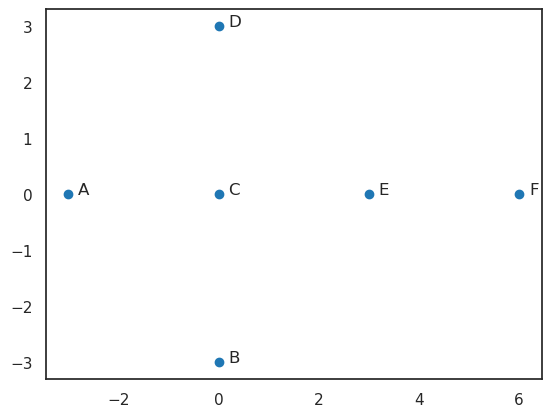

In [109]:
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]
plt.scatter(df["0"], df["1"])
for t, p in zip(string.ascii_uppercase, df.iterrows()):
    plt.annotate(t, (p[1][0] + 0.2, p[1][1]))
plt.show()

We apply the DBSCAN algorithm with:

 - `eps=3` 
 - `min_samples=4`

Lets think about what should happen:
  - The point $C$ is the only point that has `min_samples=4` or more points within a distance of `eps=3`.
    - This makes $C$ the only __core__ point in the dataset.
  - Points $A$, $B$, $D$, and $E$ are within `eps=3` units from $C$.
    - This means $A$, $B$, $D$, and $E$ will be in the same cluster as $C$.
  - Finally, point $F$ is __not__ within `eps=3` units of a core point
    - $F$ will be labeled as **noise**.


In [110]:
cluster = DBSCAN(eps=3, min_samples=4)
cluster.fit(df)
print(
    f"DBSCAN found {len(set(cluster.labels_) - set([-1]))} clusters and {(cluster.labels_ == -1).sum()} points of noise."
)

DBSCAN found 1 clusters and 1 points of noise.


Let's visualize how DBSCAN clustered our dataset:


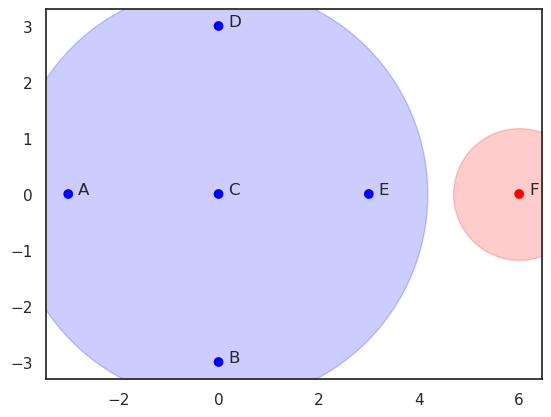

In [111]:
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]
plt.scatter(df["0"], df["1"], c=[["blue", "red"][l] for l in cluster.labels_])
plt.scatter(0, 0, c="blue", alpha=0.2, s=90000)
plt.scatter(6, 0, c="red", alpha=0.2, s=9000)
for t, p in zip(string.ascii_uppercase, df.iterrows()):
    plt.annotate(t, (p[1][0] + 0.2, p[1][1]))
plt.show()

As expected, DBSCAN found one cluster (blue) and one point of noise (red).


## **Proving Someone Has Poor Handwriting**

Suppose your friend has very difficult-to-read handwriting. As a good friend, you want to help them improve. However, they will only believe their handwriting needs improvement if you can provide some evidence.

One way to do this is to use tSNE (t-Distributed Stochastic Neighbor Embedding) to project your friend's handwriting samples into 2D space, then cluster them using DBSCAN. We can use tSNE to cluster handwritten characters from many different people and compare your friend's writing to the others.

The main idea is that if your friend writes a character poorly, the handwriting sample may:

1. Be labeled as **noise** by DBSCAN because it looks too different from the other examples.
2. Be grouped into the wrong cluster.
   - For example, if your friend writes a "5" and DBSCAN groups it with "4"s, then the character may not clearly resemble a well-written "5".

## **Pipeline Overview**

Our workflow will follow these steps:

1. **Load and scale the data**: Scaling helps ensure that all features contribute equally to the analysis.

2. **Apply: t-SNE algorithm**: t-SNE reduces high-dimensional data into a lower-dimensional space while keeping similar handwriting samples close together.

3. **Apply DBSCAN clustering**: DBSCAN groups similar handwriting samples into clusters and identifies unusual samples as noise.

4. **Visualize the results**: We will visualize the clusters to see whether your friend's handwriting differs significantly from the majority of samples.


First, we handwritten data we gathered from our friend's math assignment:


In [112]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/data/012.csv"
)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,y
0,0,0,0,0,16,13,14,14,0,0,...,0,0,0,11,15,14,14,0,0,0
1,0,16,10,0,0,0,0,0,0,0,...,14,0,0,0,0,-1,2,13,7,1
2,0,12,14,6,5,3,0,0,0,16,...,0,0,10,11,0,0,2,14,8,2



- The first 64 columns are pixel values
- `y` is the label (the true digit).


Let's visualize our data using `matplotlib`,

We will need to reshape the data into 8x8 images, so matplotlib can properly display it:


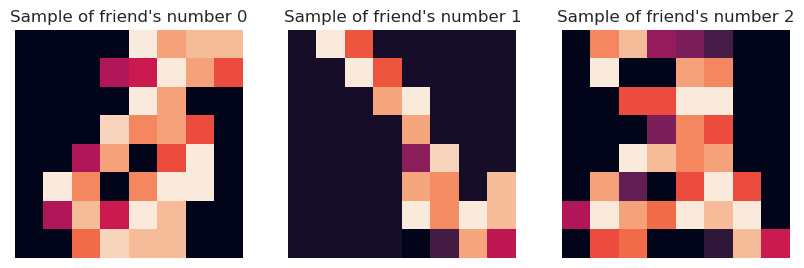

In [113]:
## Remove the target column "y"
friend_digits = df.iloc[:, df.columns != "y"].to_numpy()

## Set figure size
plt.rcParams["figure.figsize"] = (10, 8)

## Reshape the data
it = (x.reshape(8, 8) for x in friend_digits)

## Plot 3 images in one row
c = 3

## Create subplots and plot the images
fig, ax = plt.subplots(1, c, sharex="col", sharey="row")
for j in range(c):
    ## Removes tick marks and borders.
    ax[j].axis("off")
    ax[j].set_title(f"Sample of friend's number {j}")
    ax[j].imshow(next(it))
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

Next, we import the a dataset of digits from `sklearn` based on the MNIST dataset.
This data contains handwritten numbers from hundreds individuals across the United States:


In [114]:
# Load the data
digits, y = load_digits(return_X_y=True)
pd.DataFrame(digits).head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


Let's visualize our data using `matplotlib`:


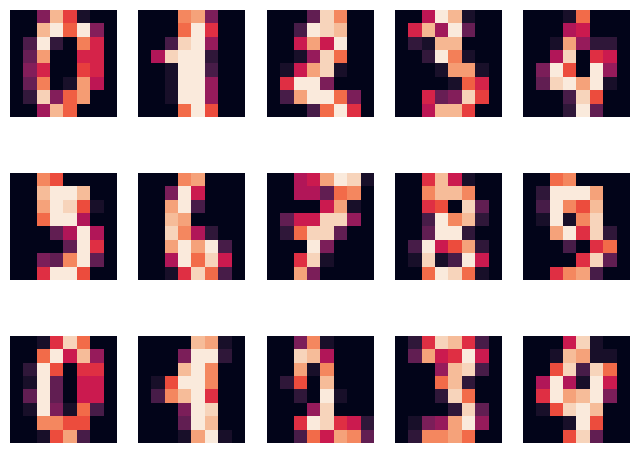

In [115]:
plt.rcParams["figure.figsize"] = (8, 6)
it = (x.reshape(8, 8) for x in digits)
r, c = 3, 5
fig, ax = plt.subplots(r, c, sharex="col", sharey="row")
for i in range(r):
    for j in range(c):
        ax[i, j].axis("off")
        ax[i, j].imshow(next(it))
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

Now we create the dataset for our pipeline, containing _both_ MNIST and our friend's digits:


In [116]:
# Use np.r_ to concatenate two rows:
data = np.r_[digits, friend_digits]
y = np.r_[y, df["y"]]

Next, we initialize the objects for our pipeline, with our chosen hyperparameters:


In [117]:
embedding = TSNE(
    n_components=2,
    init="pca",
    max_iter=500,
    n_iter_without_progress=150,
    perplexity=10,
    random_state=0,
)

In [118]:
e_data = embedding.fit_transform(data)

Our data after applying `TSNE` algorithm:


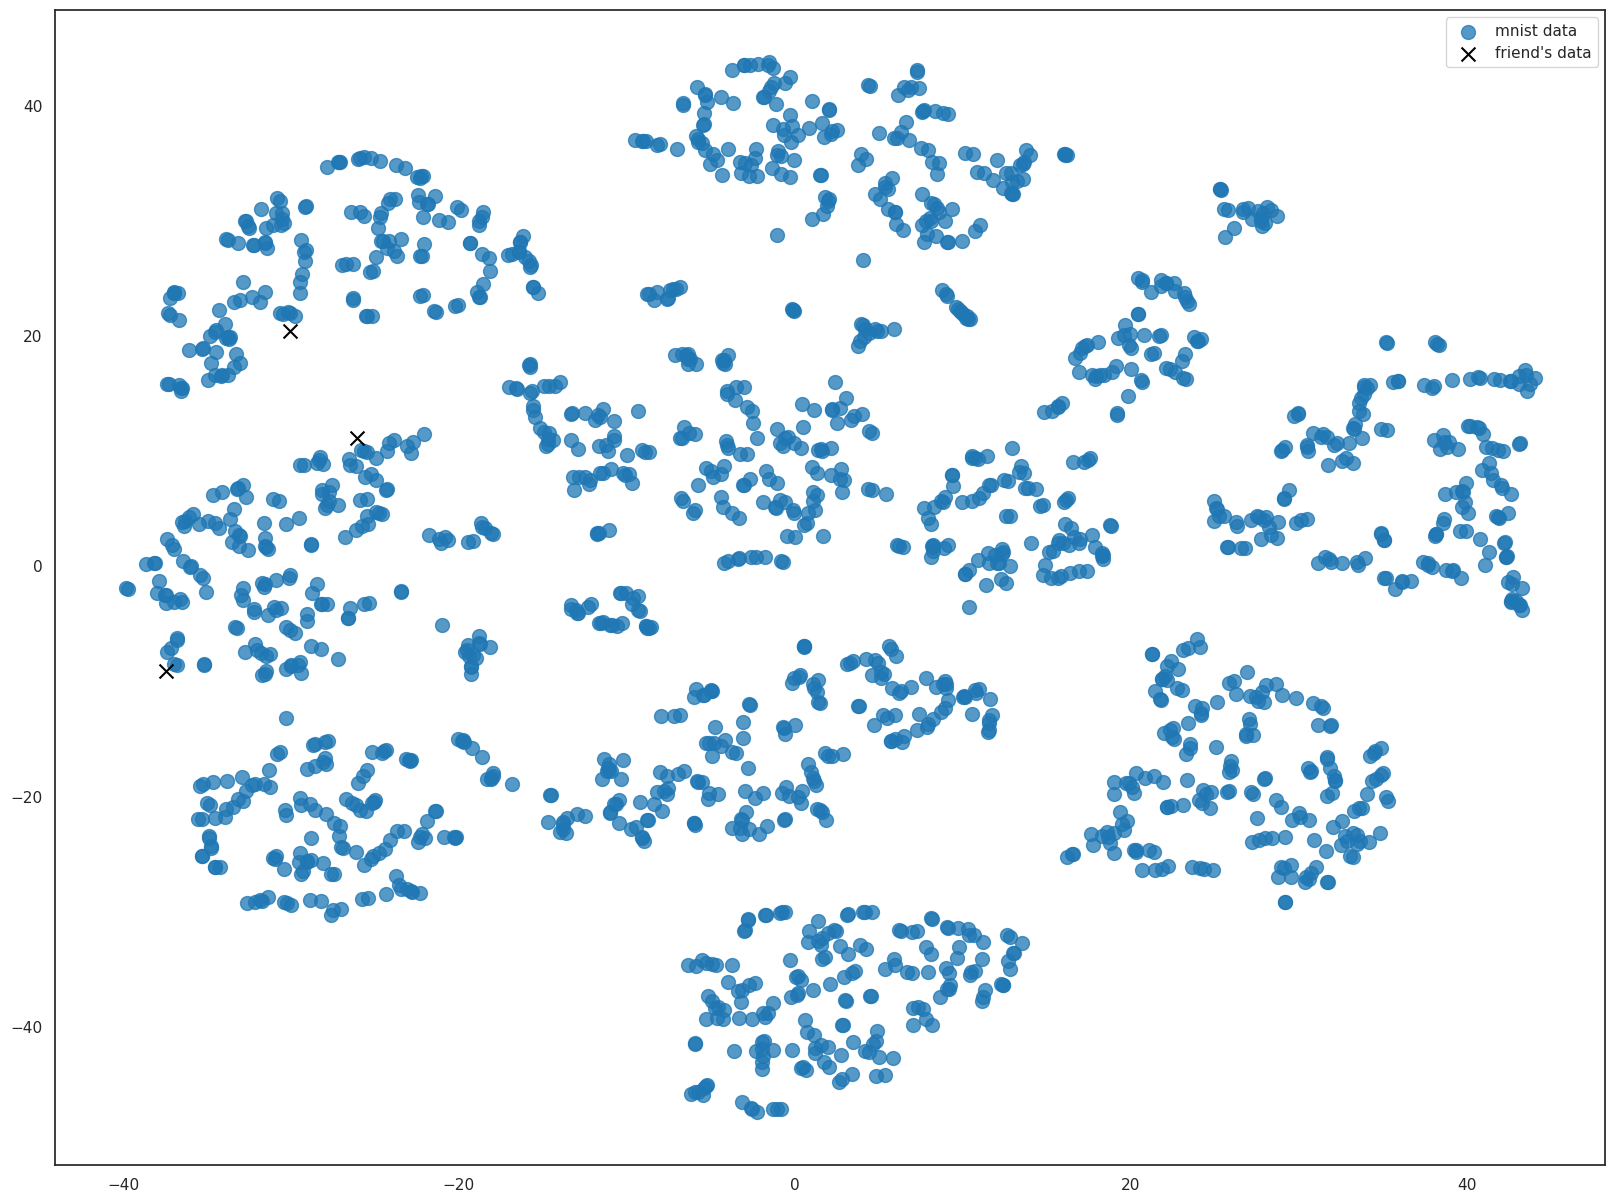

In [ ]:
plt.rcParams["figure.figsize"] = (20, 15)
n = friend_digits.shape[0]  # number of friend's data points

plt.scatter(
    e_data[:-n, 0],  # the first column of e_data except the last n rows
    e_data[:-n, 1],  # the second column of e_data except the last n rows
    marker="o",
    alpha=0.75,
    label="mnist data",
    s=100,
)

plt.scatter(
    e_data[-n:, 0],  # the first column of e_data for the last n rows
    e_data[-n:, 1],  # the second column of e_data for the last n rows
    marker="x",
    color="black",
    label="friend's data",
    alpha=1,
    s=100,
)

plt.legend(bbox_to_anchor=[1, 1])
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

Next, we apply DBSCAN, using our chosen hyperparameters:

**DBSCAN use -1 to mean noise point or outlier**


In [120]:
cluster = DBSCAN(eps=5, min_samples=20)
cluster.fit(e_data)
print(
    f"DBSCAN found {len(set(cluster.labels_) - set([-1]))} clusters and {(cluster.labels_ == -1).sum()} points of noise."
)

DBSCAN found 11 clusters and 24 points of noise.


Let's visualize our data again, categorized by DBSCAN:


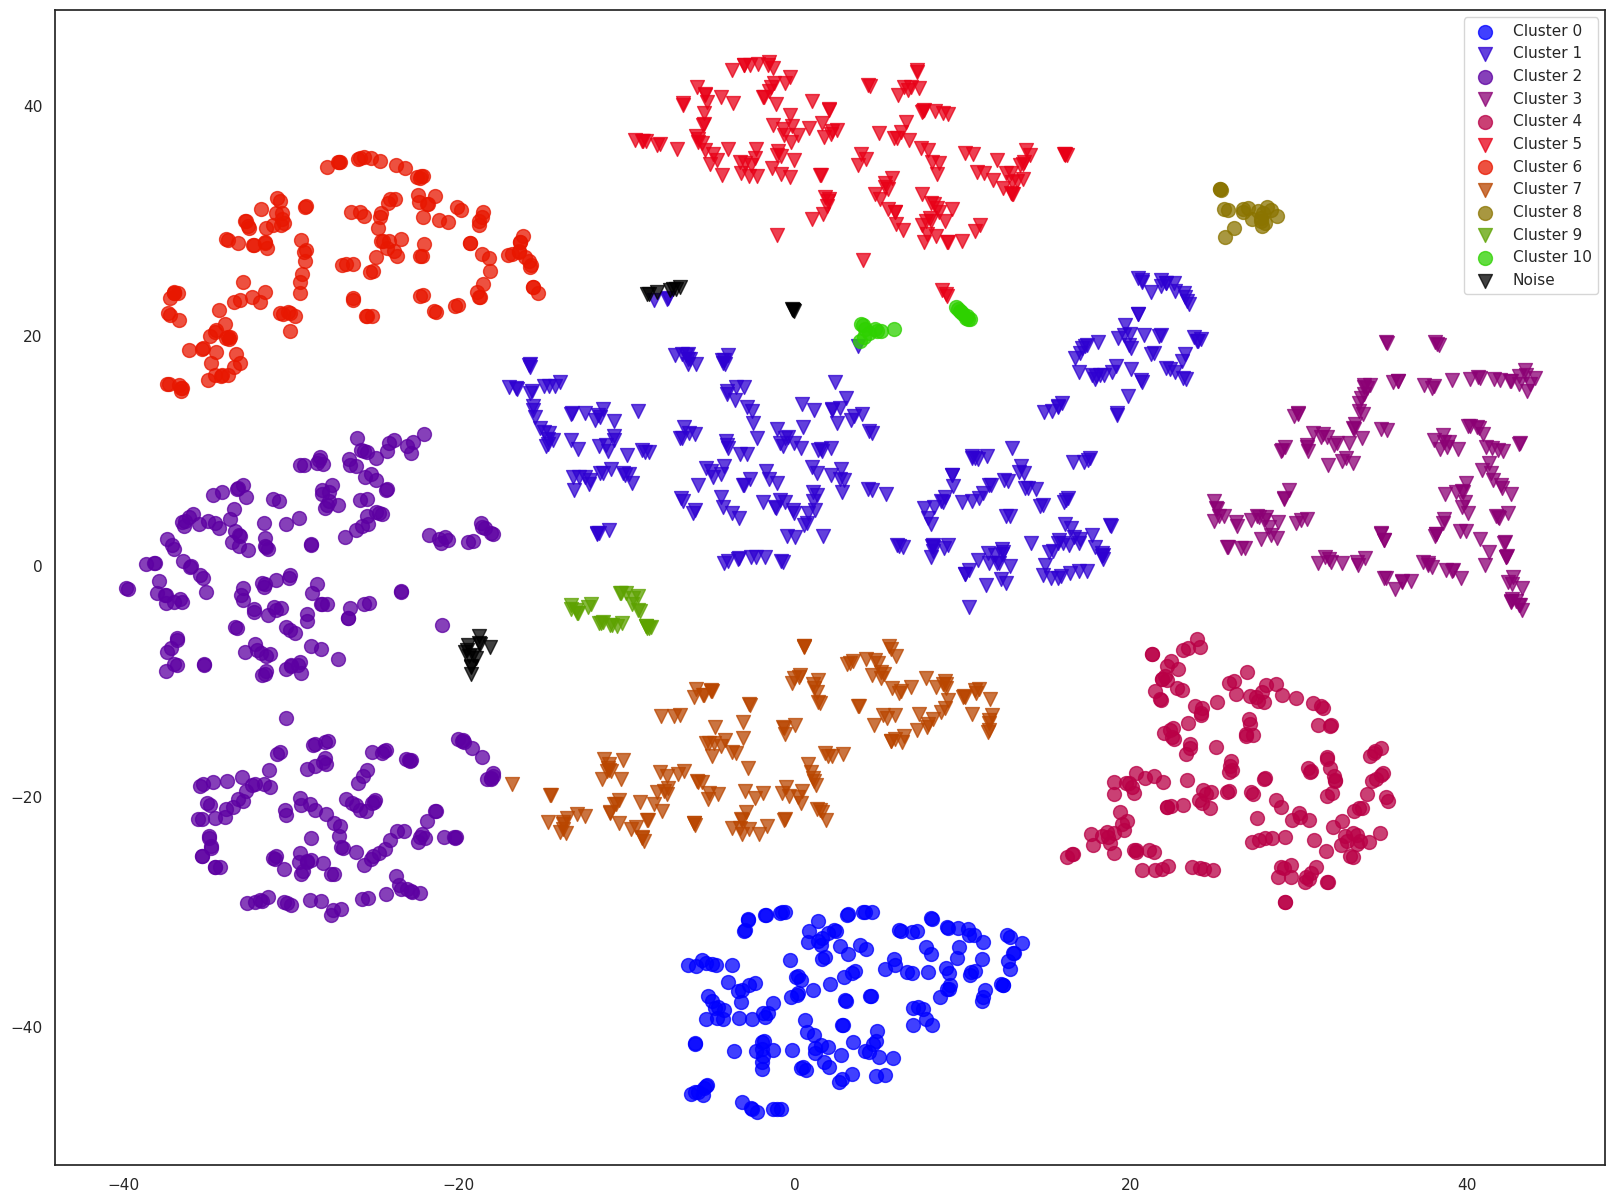

In [ ]:
plt.rcParams["figure.figsize"] = (20, 15)
unique_labels = set(cluster.labels_)  # Get the unique cluster labels
n_labels = len(
    unique_labels
)  # Get the number of unique cluster labels (including noise if present)
cmap = plt.cm.get_cmap("brg", n_labels)
for l in unique_labels:
    plt.scatter(
        e_data[
            cluster.labels_ == l, 0
        ],  # the first column of e_data for the points in cluster as x-axis
        e_data[
            cluster.labels_ == l, 1
        ],  #  the second column of e_data for the points in cluster as y-axis
        c=[
            cmap(l) if l >= 0 else "Black"
        ],  # color each cluster a different color
        marker="ov"[l % 2],  # marker for each cluster
        alpha=0.75,
        s=100,  # size of the marker
        label=f"Cluster {l}" if l >= 0 else "Noise",  # legend for each cluster
    )
plt.legend(bbox_to_anchor=[1, 1])
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

In [122]:
print("The predicted labels of our friend's handwriting:")
print(cluster.labels_[-3:])

The predicted labels of our friend's handwriting:
[2 6 2]


Let's see how our pipeline categorized some of the data in its original, handwritten form:


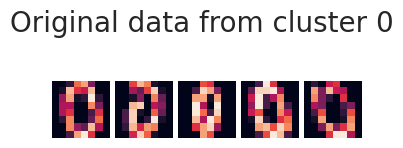

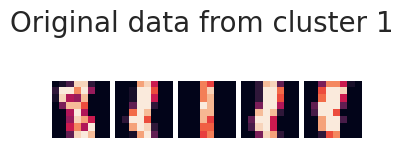

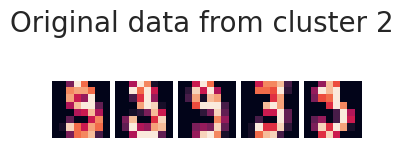

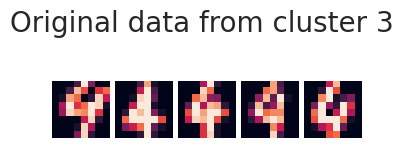

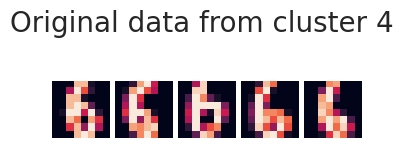

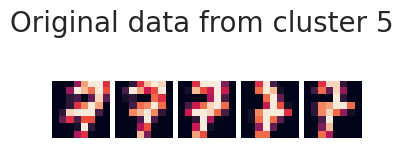

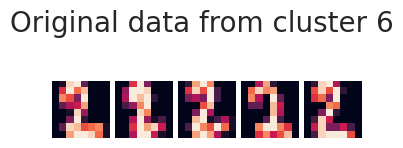

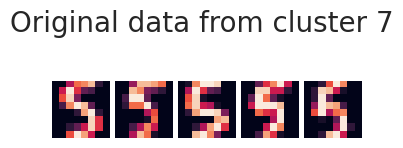

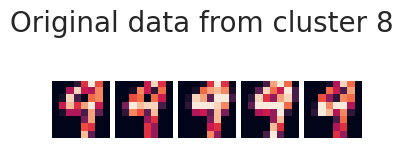

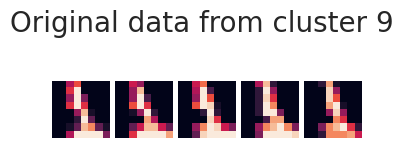

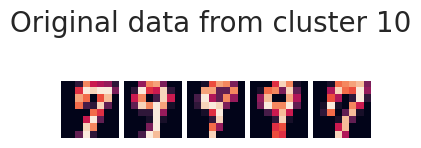

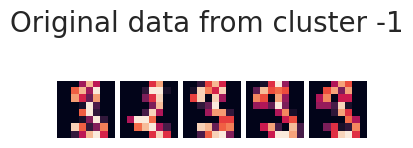

In [123]:
r, c = 1, 5
plt.rcParams["figure.figsize"] = (4 * r, 4 * c)
for label in unique_labels:
    cluster_data = data[cluster.labels_ == label]
    nums = cluster_data[
        np.random.choice(len(cluster_data), r * c, replace=False)
    ]
    it = (x.reshape(8, 8) for x in nums)
    fig, ax = plt.subplots(r, c)
    ax = ax.reshape(r, c)
    plt.subplots_adjust(wspace=0.1, hspace=-0.69)
    fig.suptitle(f"Original data from cluster {label}", fontsize=20, y=0.545)
    for i in range(r):
        for j in range(c):
            ax[i, j].axis("off")
            ax[i, j].imshow(next(it))
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

In this case we do have the original labels,

Let's compare `DBSCAN`'s clusters to the actual labels:


Correct labels:


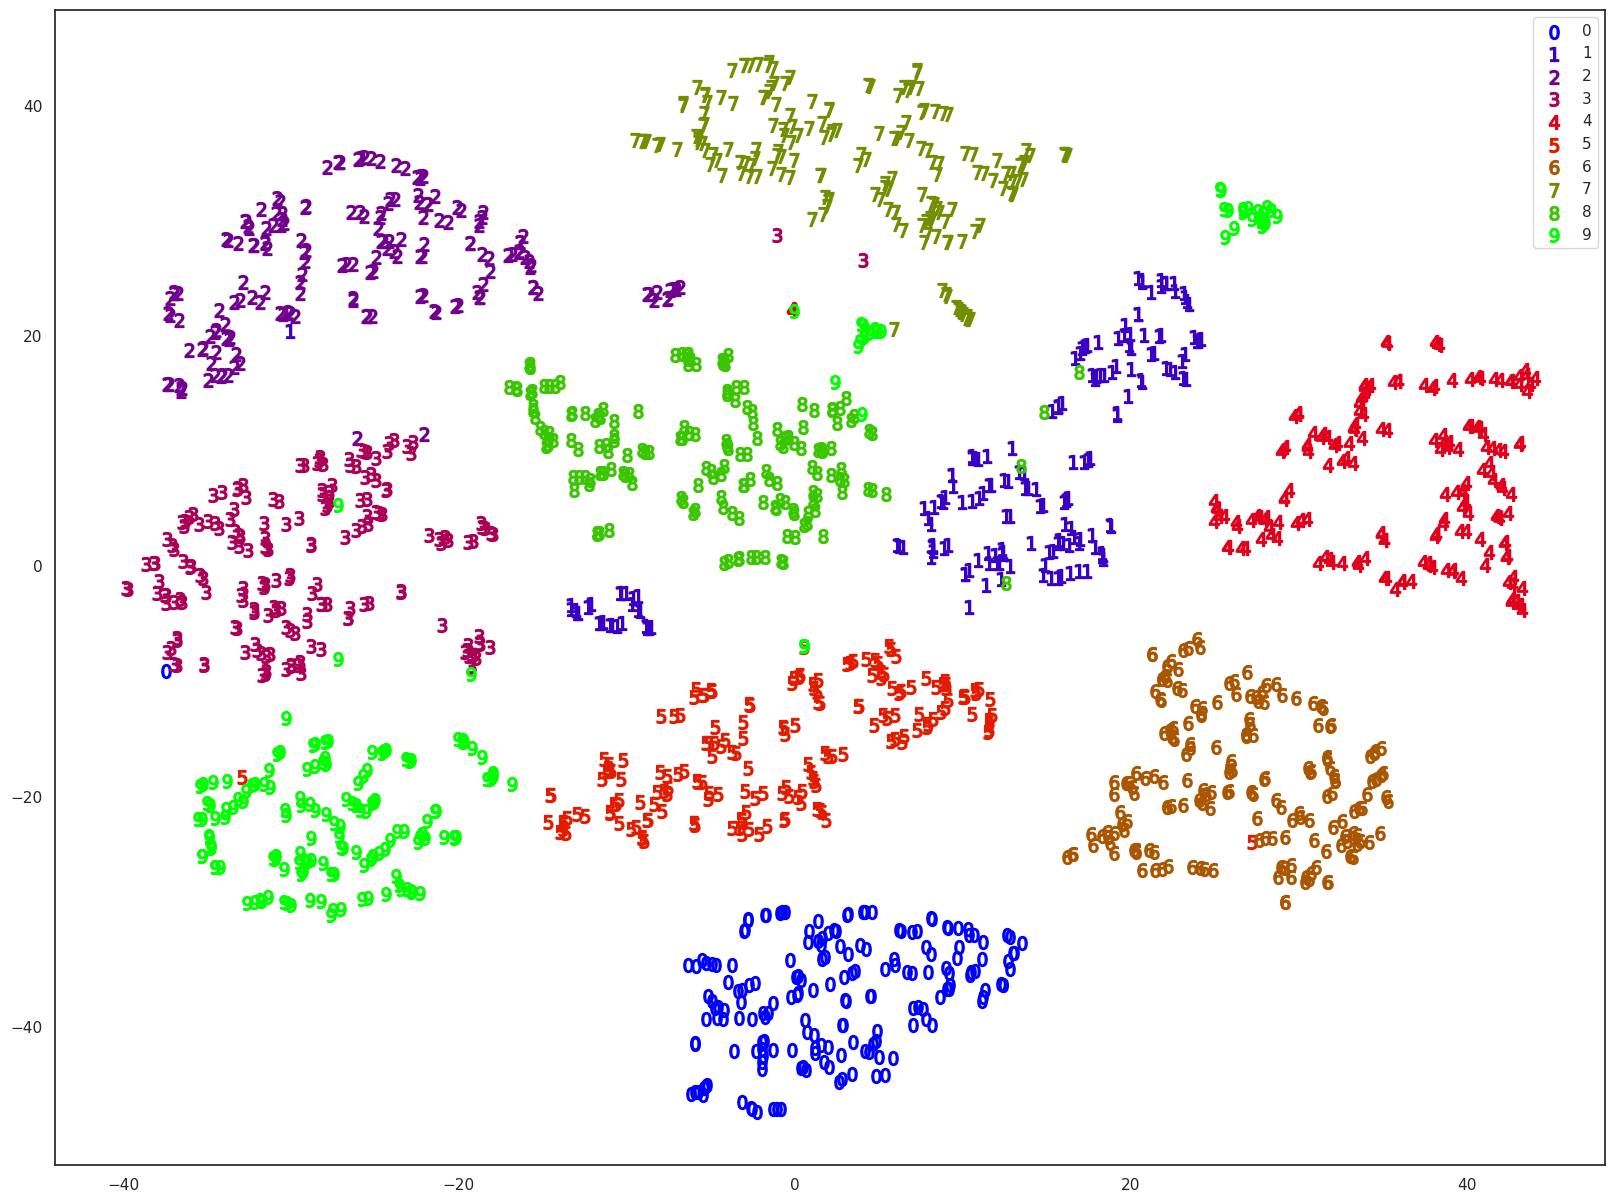

In [124]:
print("Correct labels:")
plt.rcParams["figure.figsize"] = (20, 15)

unique_labels = set(y)
n_labels = len(unique_labels)
cmap = plt.cm.get_cmap("brg", n_labels)
for l in unique_labels:
    plt.scatter(
        e_data[y == l, 0],
        e_data[y == l, 1],
        c=[cmap(l)],
        marker=f"${l}$",
        alpha=1,
        label=f"{l}",
        s=100,
    )
plt.legend(bbox_to_anchor=[1, 1])
plt.show()

Finally, we can prove our friend's handwriting is unreadable (even for state-of-the-art unsupervised algorithms):


In [125]:
for i, (l, t) in enumerate(zip(cluster.labels_[-3:], y[-3:])):
    print("-" * 30)
    print(
        f"Your friend's {i}th sample was categorized as being in cluster #{l}"
    )
    if l == -1:
        print("(IE: Noise)")
    else:
        v, c = np.unique(y[cluster.labels_ == l], return_counts=True)
        mfreq = v[np.argmax(c)]
        ratio = c.max() / c.sum()
        print(f"Cluster {l} is {ratio * 100:.2f}% the number {mfreq}")

    print(f"Your friend's {i}th sample is supposed to be the number {t}")

------------------------------
Your friend's 0th sample was categorized as being in cluster #2
Cluster 2 is 53.48% the number 3
Your friend's 0th sample is supposed to be the number 0
------------------------------
Your friend's 1th sample was categorized as being in cluster #6
Cluster 6 is 99.40% the number 2
Your friend's 1th sample is supposed to be the number 1
------------------------------
Your friend's 2th sample was categorized as being in cluster #2
Cluster 2 is 53.48% the number 3
Your friend's 2th sample is supposed to be the number 2


As you can see, all our friend's data was either categorized as noise, or put in a category where the vast majority is a different number.


## **Exercises**

In this section, you can practice using `DBSCAN` by applying the algorithm on different datasets.

Please run the following code to acquire the dataset for the exercises:


In [126]:
df = pd.read_csv(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML0187EN-SkillsNetwork/labs/module%202/data/DBSCAN_exercises.csv"
)
df.head()

,x,y
0,-4.792194,-9.720065
1,-0.102493,20.667312
2,-2.998773,7.034104
3,13.348503,-16.374098
4,6.827445,10.782092


Here's what the data looks like:


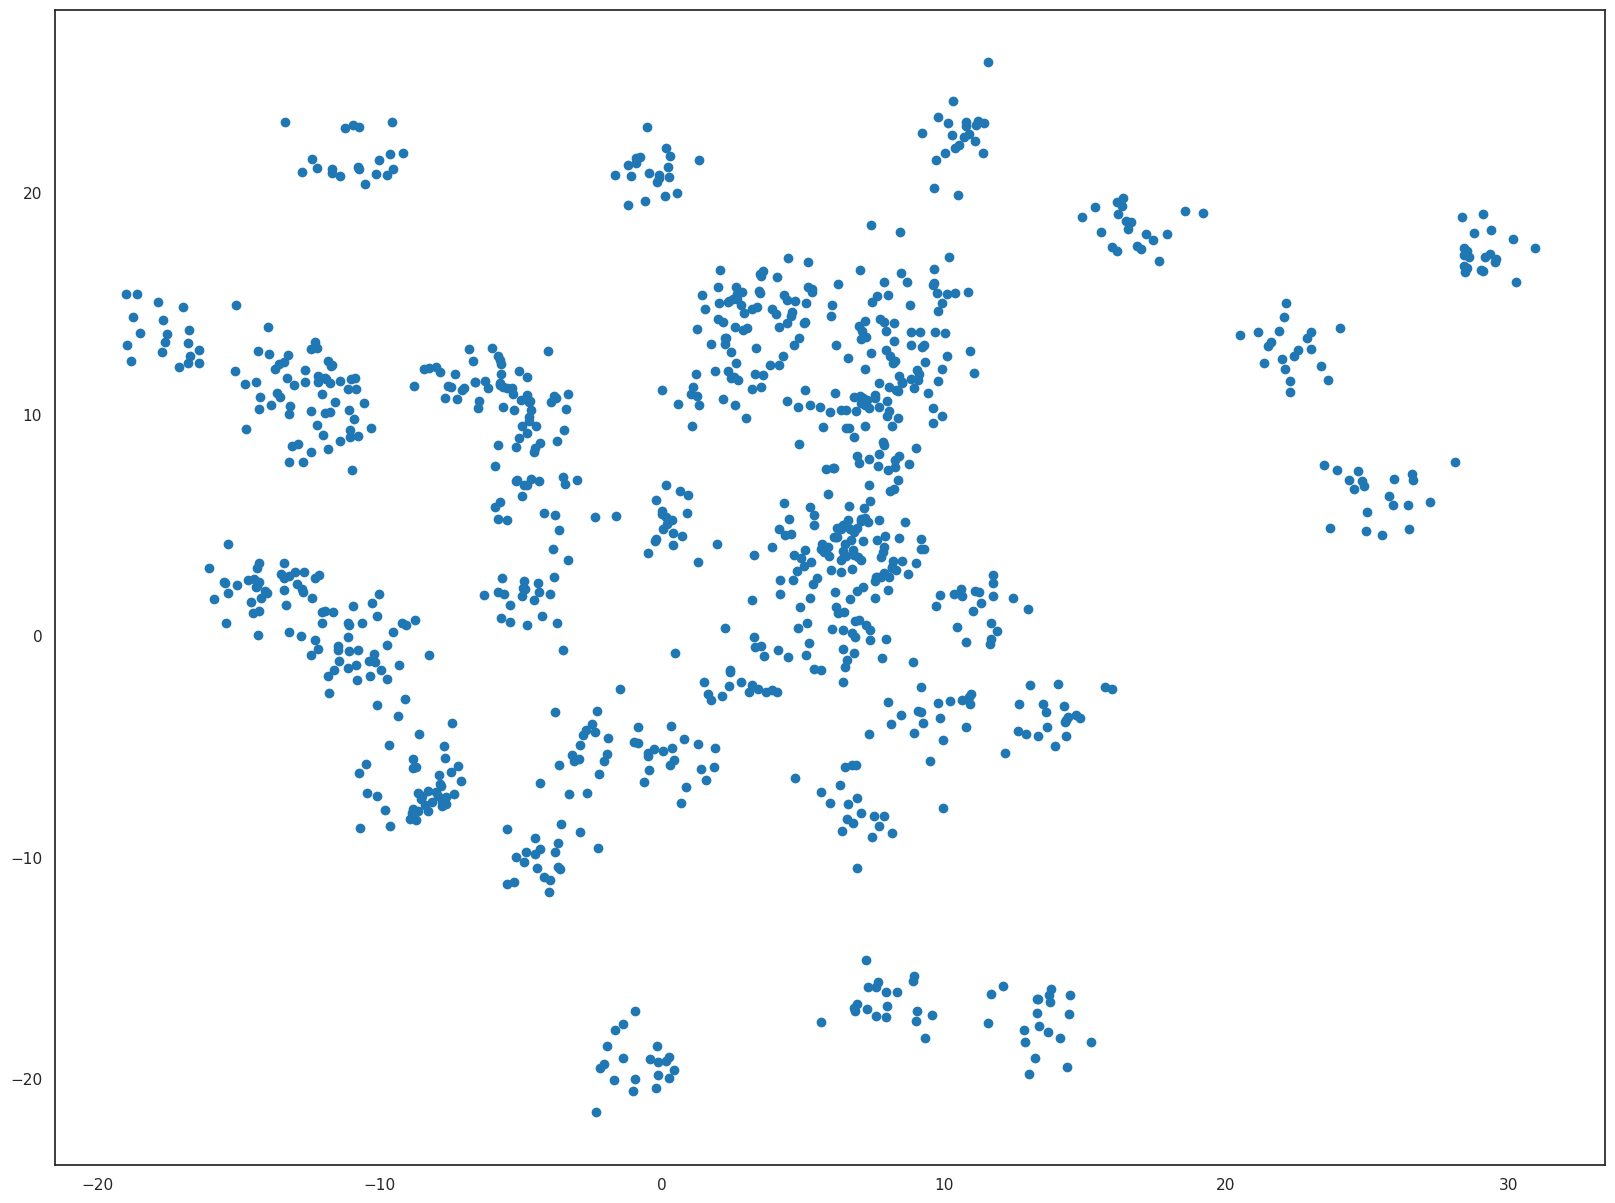

In [127]:
plt.scatter(df["x"], df["y"])
plt.show()

### **Exercise 1 - Find the number of clusters**

Find the number of clusters with:
   - `eps=2`
   - `min_samples=10`

(Not including noise).


In [132]:
# TODO

cluster = DBSCAN(eps=2, min_samples=10)
cluster.fit(df)
print(len(set(cluster.labels_) - {1}))

15


### **Exercise 2 - Find the % of data marked as noise**

Using the fitted `DBSCAN` object from the previous exercise, find % of the data that was marked as noise:


In [133]:
noise_percentage = (cluster.labels_ == -1).sum() / len(cluster.labels_) * 100
print(f"{noise_percentage:.2f}% of the data was marked as noise.")

0.30% of the data was marked as noise.


### **Exercise 3 - Visualize the clustered data using matplotlib.pyplot**

It's very useful to visualize your clustered data when possible (i.e., when dimension is low enough);

Using `matplotlib.pyplot`, visualize the clustered data - where each cluster has its own assigned color.


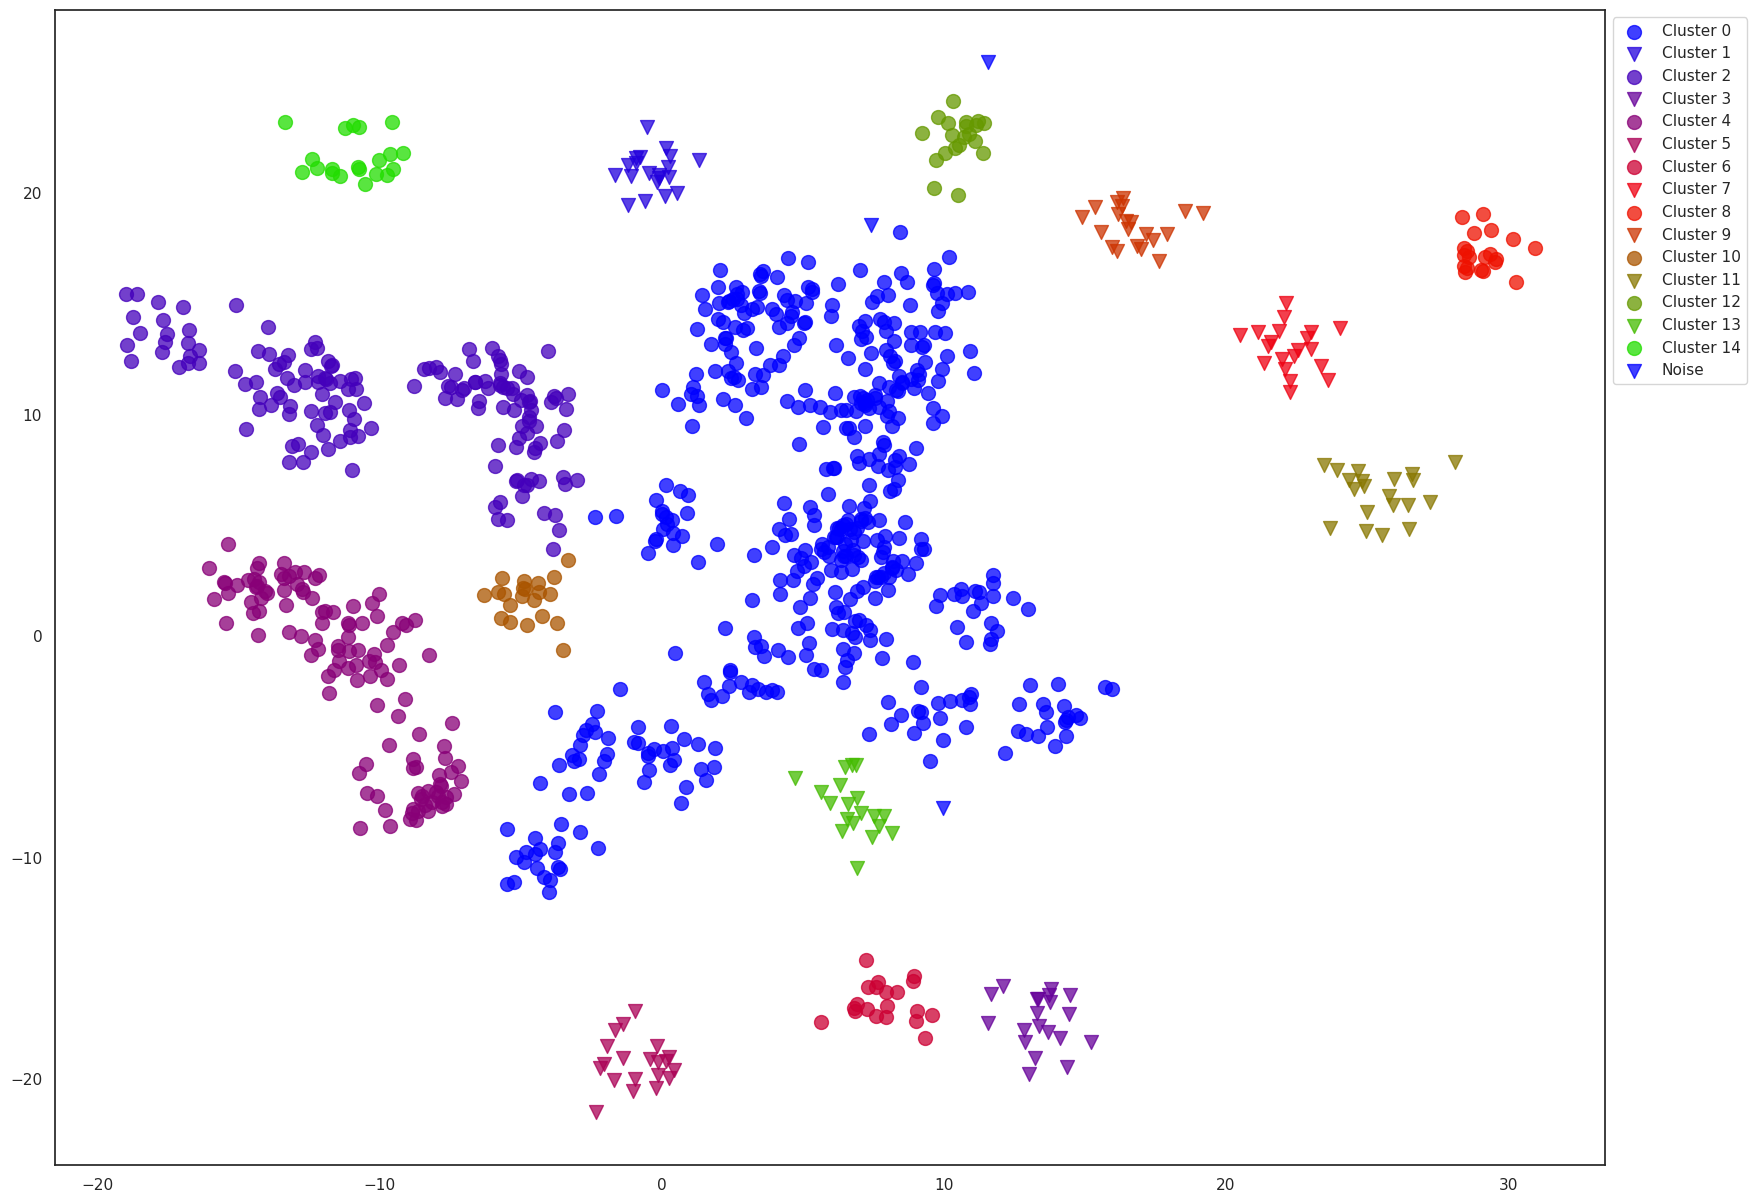

In [134]:
# TODO

plt.rcParams["figure.figsize"] = (20, 15)
unique_labels = set(cluster.labels_)
n_labels = len(unique_labels)
cmap = plt.cm.get_cmap("brg", n_labels)
for l in unique_labels:
    plt.scatter(
        df["x"][cluster.labels_ == l],
        df["y"][cluster.labels_ == l],
        c=[cmap(l)],
        marker="ov"[l % 2],
        alpha=0.75,
        s=100,
        label=f"Cluster {l}" if l >= 0 else "Noise",
    )
plt.legend(bbox_to_anchor=[1, 1])
plt.show()
plt.rcParams["figure.figsize"] = plt.rcParamsDefault["figure.figsize"]

## **Authors**


[Sam Prokopchuk](https://www.linkedin.com/in/sam-prokopchuk-1908b21a0/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01)

Su Wu


### **Other Contributors**


[Roxanne Li](https://www.linkedin.com/in/roxanne-li/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork821-2023-01-01) is a Data Science intern at IBM Skills Network, entering level-5 study in the Mathematics & Statistics undergraduate Coop program at McMaster University.


## **Change Log**


|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2021-12-20|0.1|Sam Prokopchuk|Complete Exercises' content|
|2022-05-20|0.2|Roxanne Li|Review and edit|
|2022-07-18|0.2|Svitlana K |Review and edit|
| 2026-05-11        | 0.3     | Su Wu       | Documentation and code edits|

Copyright © 2021 IBM Corporation. All rights reserved.
